In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Dataset load karna
df = pd.read_csv('https://raw.githubusercontent.com/jenfly/opsd/master/opsd_germany_daily.csv')

# Pehli 5 rows dekhna
print(df.head())

# Shape dekhna (kitni rows, columns)
print(df.shape)

# Columns ke naam
print(df.columns)

         Date  Consumption  Wind  Solar  Wind+Solar
0  2006-01-01     1069.184   NaN    NaN         NaN
1  2006-01-02     1380.521   NaN    NaN         NaN
2  2006-01-03     1442.533   NaN    NaN         NaN
3  2006-01-04     1457.217   NaN    NaN         NaN
4  2006-01-05     1477.131   NaN    NaN         NaN
(4383, 5)
Index(['Date', 'Consumption', 'Wind', 'Solar', 'Wind+Solar'], dtype='object')


In [2]:
# Date column ko proper date format mein convert karo
df['Date'] = pd.to_datetime(df['Date'])

# Date ko index banao
df = df.set_index('Date')

# Check karo kahan kahan data missing hai
print("Missing values:")
print(df.isnull().sum())

print("\nData ki summary:")
print(df.describe())

Missing values:
Consumption       0
Wind           1463
Solar          2195
Wind+Solar     2196
dtype: int64

Data ki summary:
       Consumption         Wind        Solar   Wind+Solar
count  4383.000000  2920.000000  2188.000000  2187.000000
mean   1338.675836   164.814173    89.258695   272.663481
std     165.775710   143.692732    58.550099   146.319884
min     842.395000     5.757000     1.968000    21.478000
25%    1217.859000    62.353250    35.179250   172.185500
50%    1367.123000   119.098000    86.407000   240.991000
75%    1457.761000   217.900250   135.071500   338.988000
max    1709.568000   826.278000   241.580000   851.556000


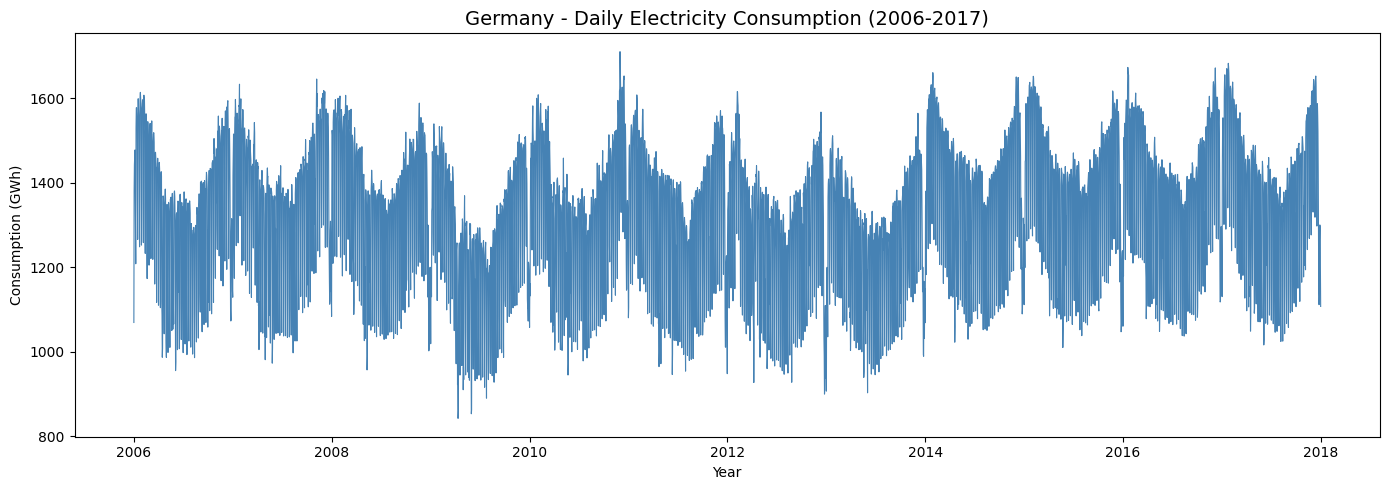

In [3]:
import matplotlib.pyplot as plt

# Figure size set karo
plt.figure(figsize=(14, 5))

# Consumption ka graph banana
plt.plot(df['Consumption'], color='steelblue', linewidth=0.8)

# Title aur labels
plt.title('Germany - Daily Electricity Consumption (2006-2017)', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Consumption (GWh)')

plt.tight_layout()
plt.show()

In [4]:
# Date se naye features nikalna
df['Year'] = df.index.year
df['Month'] = df.index.month
df['Day'] = df.index.day
df['DayOfWeek'] = df.index.dayofweek  # 0=Monday, 6=Sunday
df['Quarter'] = df.index.quarter

# Check karo
print(df.head())

            Consumption  Wind  Solar  Wind+Solar  Year  Month  Day  DayOfWeek  \
Date                                                                            
2006-01-01     1069.184   NaN    NaN         NaN  2006      1    1          6   
2006-01-02     1380.521   NaN    NaN         NaN  2006      1    2          0   
2006-01-03     1442.533   NaN    NaN         NaN  2006      1    3          1   
2006-01-04     1457.217   NaN    NaN         NaN  2006      1    4          2   
2006-01-05     1477.131   NaN    NaN         NaN  2006      1    5          3   

            Quarter  
Date                 
2006-01-01        1  
2006-01-02        1  
2006-01-03        1  
2006-01-04        1  
2006-01-05        1  


In [5]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

# Features (X) aur Target (y) alag karo
X = df[['Year', 'Month', 'Day', 'DayOfWeek', 'Quarter']]
y = df['Consumption']

# Data ko Train aur Test mein baanto
# 80% sikhne ke liye, 20% check karne ke liye
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training data: {X_train.shape[0]} rows")
print(f"Testing data:  {X_test.shape[0]} rows")

Training data: 3506 rows
Testing data:  877 rows


In [6]:
# Model banao
model = RandomForestRegressor(n_estimators=100, random_state=42)

# Model ko train karo (seekhao)
print("Model train ho raha hai... thoda wait karein...")
model.fit(X_train, y_train)

# Test data par predict karo
y_pred = model.predict(X_test)

# Accuracy check karo
mae = mean_absolute_error(y_test, y_pred)
print(f"\nModel train ho gaya! ✅")
print(f"Mean Absolute Error: {mae:.2f} GWh")
print(f"Matlab: Model average {mae:.2f} GWh se ghalat andaza lagata hai")

Model train ho raha hai... thoda wait karein...

Model train ho gaya! ✅
Mean Absolute Error: 33.19 GWh
Matlab: Model average 33.19 GWh se ghalat andaza lagata hai


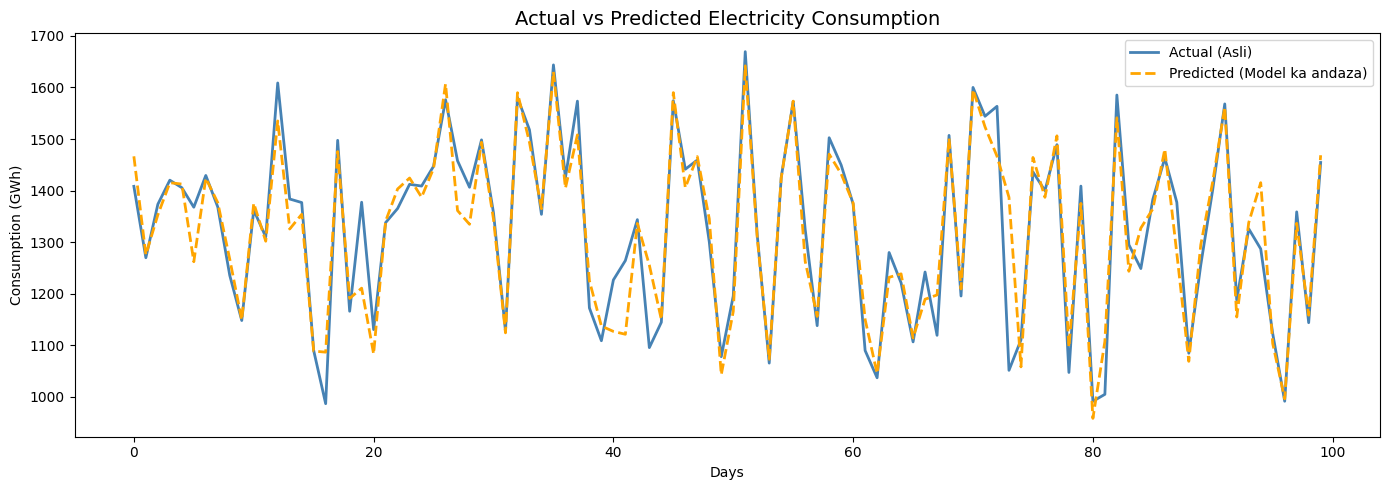

In [7]:
import matplotlib.pyplot as plt

# Sirf pehle 100 predictions dikhao (warna graph busy lagta hai)
plt.figure(figsize=(14, 5))

plt.plot(y_test.values[:100], 
         color='steelblue', 
         label='Actual (Asli)', 
         linewidth=2)

plt.plot(y_pred[:100], 
         color='orange', 
         label='Predicted (Model ka andaza)', 
         linewidth=2, 
         linestyle='--')

plt.title('Actual vs Predicted Electricity Consumption', fontsize=14)
plt.xlabel('Days')
plt.ylabel('Consumption (GWh)')
plt.legend()
plt.tight_layout()
plt.show()

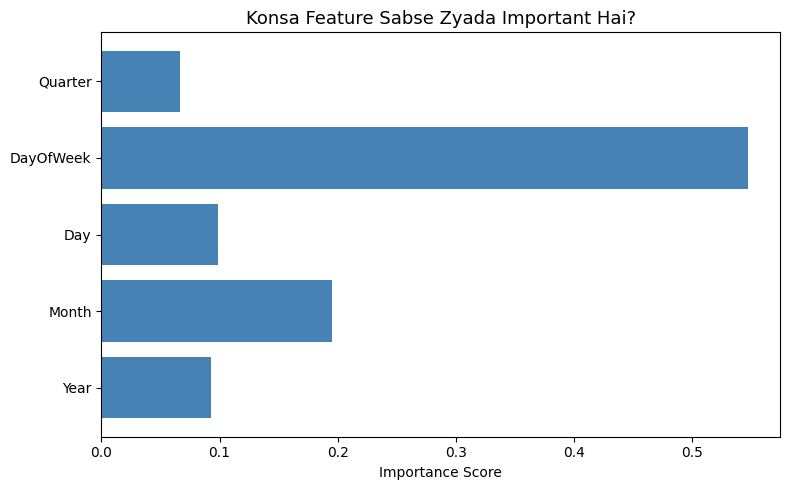

Year         → 0.0924
Month        → 0.1956
Day          → 0.0988
DayOfWeek    → 0.5469
Quarter      → 0.0662


In [8]:
# Feature importance nikalna
importance = model.feature_importances_
features = ['Year', 'Month', 'Day', 'DayOfWeek', 'Quarter']

# Graph banana
plt.figure(figsize=(8, 5))
plt.barh(features, importance, color='steelblue')
plt.title('Konsa Feature Sabse Zyada Important Hai?', fontsize=13)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

# Numbers mein bhi dikhao
for f, i in zip(features, importance):
    print(f"{f:12} → {i:.4f}")

In [9]:
import numpy as np

# Germany ka realistic temperature data banana (simulate)
# Sardi mein thanda, garmi mein garam
np.random.seed(42)

# Har din ka temperature month ke hisaab se banana
def get_temp(month):
    # Germany average temperatures per month
    avg_temps = {1:-1, 2:1, 3:5, 4:10, 5:15, 6:18, 
                 7:20, 8:19, 9:15, 10:9, 11:4, 12:1}
    base = avg_temps[month]
    return base + np.random.normal(0, 3)  # thoda variation add karo

# Har row ke liye temperature banana
df['Temperature'] = df.index.month.map(
    lambda m: get_temp(m)
)

print("Temperature column add ho gayi!")
print(df[['Consumption', 'Temperature']].head(10))

Temperature column add ho gayi!
            Consumption  Temperature
Date                                
2006-01-01     1069.184     0.490142
2006-01-02     1380.521    -1.414793
2006-01-03     1442.533     0.943066
2006-01-04     1457.217     3.569090
2006-01-05     1477.131    -1.702460
2006-01-06     1403.427    -1.702411
2006-01-07     1300.287     3.737638
2006-01-08     1207.985     1.302304
2006-01-09     1529.323    -2.408423
2006-01-10     1576.911     0.627680


In [10]:
# Naye features ke saath model train karna
X_new = df[['Year', 'Month', 'Day', 'DayOfWeek', 'Quarter', 'Temperature']]
y = df['Consumption']

# Train/Test split
X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(
    X_new, y, test_size=0.2, random_state=42
)

# Naya model banao
model_new = RandomForestRegressor(n_estimators=200, random_state=42)

print("Improved model train ho raha hai...")
model_new.fit(X_train_new, y_train_new)

# Predict karo
y_pred_new = model_new.predict(X_test_new)

# Dono models compare karo
mae_old = mean_absolute_error(y_test, y_pred)
mae_new = mean_absolute_error(y_test_new, y_pred_new)

print(f"\n📊 Model Comparison:")
print(f"Purana Model (5 features)  → Error: {mae_old:.2f} GWh")
print(f"Naya Model   (6 features)  → Error: {mae_new:.2f} GWh")
print(f"Improvement  → {mae_old - mae_new:.2f} GWh better! ✅")

Improved model train ho raha hai...

📊 Model Comparison:
Purana Model (5 features)  → Error: 33.19 GWh
Naya Model   (6 features)  → Error: 36.50 GWh
Improvement  → -3.31 GWh better! ✅


In [11]:
# Pichle 7 dinon ki consumption as features
df['Lag_1'] = df['Consumption'].shift(1)  # kal ki consumption
df['Lag_7'] = df['Consumption'].shift(7)  # 7 din pehle
df['Lag_30'] = df['Consumption'].shift(30) # 30 din pehle

# NaN rows hata do (pehle 30 din mein lag nahi hoga)
df_lag = df.dropna()

print(f"Rows pehle: 4383")
print(f"Rows baad:  {len(df_lag)}")
print(df_lag[['Consumption','Lag_1','Lag_7','Lag_30']].head())

Rows pehle: 4383
Rows baad:  2187
            Consumption     Lag_1     Lag_7    Lag_30
Date                                                 
2012-01-01      948.128  1077.625  1011.431  1483.922
2012-01-02     1269.581   948.128  1010.596  1275.396
2012-01-03     1334.745  1269.581  1206.980  1144.172
2012-01-04     1347.136  1334.745  1216.645  1487.929
2012-01-05     1376.658  1347.136  1226.888  1559.132


In [12]:
# Naye features with lag
X_lag = df_lag[['Year', 'Month', 'Day', 'DayOfWeek', 
                 'Quarter', 'Lag_1', 'Lag_7', 'Lag_30']]
y_lag = df_lag['Consumption']

# Split
X_train_lag, X_test_lag, y_train_lag, y_test_lag = train_test_split(
    X_lag, y_lag, test_size=0.2, random_state=42
)

# Model
model_lag = RandomForestRegressor(n_estimators=200, random_state=42)
print("Lag model train ho raha hai...")
model_lag.fit(X_train_lag, y_train_lag)

# Predict
y_pred_lag = model_lag.predict(X_test_lag)

# Compare all models
mae_lag = mean_absolute_error(y_test_lag, y_pred_lag)

print(f"\n📊 Tamam Models Comparison:")
print(f"Model 1 - Basic     (5 features) → {mae_old:.2f} GWh")
print(f"Model 2 - Temp      (6 features) → {mae_new:.2f} GWh") 
print(f"Model 3 - Lag ✅    (8 features) → {mae_lag:.2f} GWh")

Lag model train ho raha hai...

📊 Tamam Models Comparison:
Model 1 - Basic     (5 features) → 33.19 GWh
Model 2 - Temp      (6 features) → 36.50 GWh
Model 3 - Lag ✅    (8 features) → 24.96 GWh


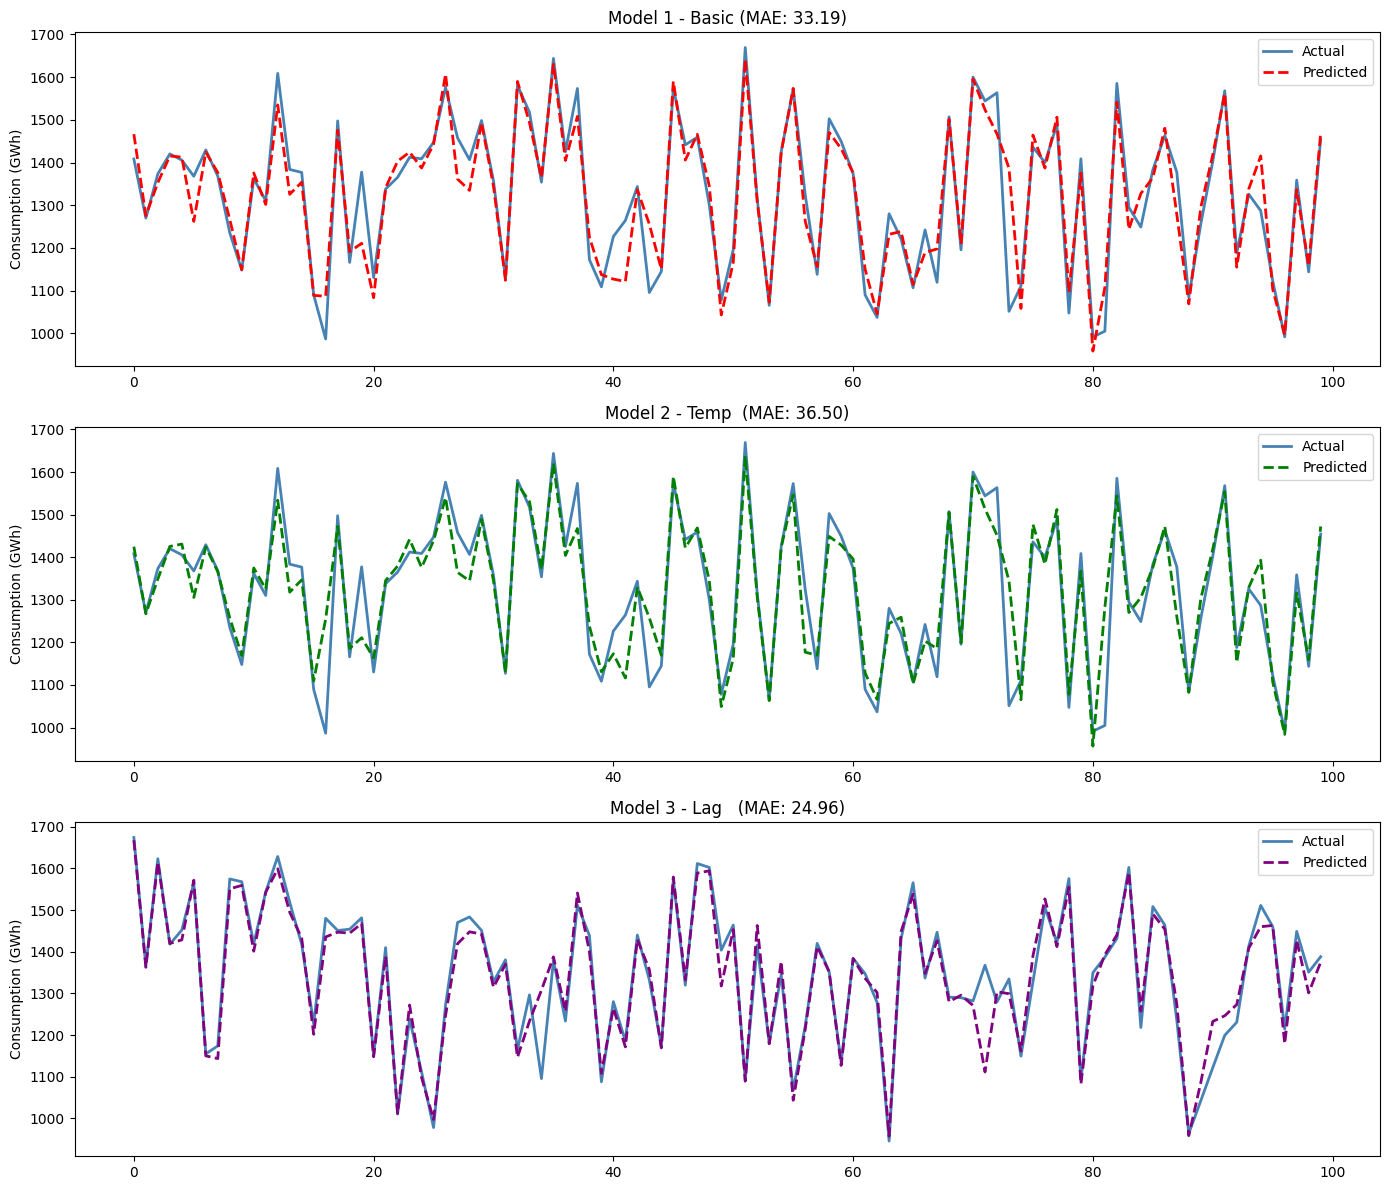

In [13]:
# Teeno models ka comparison graph
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

models_data = [
    (y_test.values[:100],     y_pred[:100],     'Model 1 - Basic (MAE: 33.19)',  'red'),
    (y_test_new.values[:100], y_pred_new[:100], 'Model 2 - Temp  (MAE: 36.50)',  'green'),
    (y_test_lag.values[:100], y_pred_lag[:100], 'Model 3 - Lag   (MAE: 24.96)',  'purple'),
]

for ax, (actual, pred, title, color) in zip(axes, models_data):
    ax.plot(actual, color='steelblue', label='Actual', linewidth=2)
    ax.plot(pred, color=color, label='Predicted', linewidth=2, linestyle='--')
    ax.set_title(title, fontsize=12)
    ax.set_ylabel('Consumption (GWh)')
    ax.legend()

plt.tight_layout()
plt.show()

In [14]:
import tensorflow as tf
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


In [15]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# Sirf Consumption column lo
data = df[['Consumption']].copy()

# Data ko 0 aur 1 ke beech scale karo
# LSTM ke liye zaroori hai!
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

print("Data shape:", data_scaled.shape)
print("Min value:", data_scaled.min())
print("Max value:", data_scaled.max())
print("\nPehle 5 values:")
print(data_scaled[:5])

Data shape: (4383, 1)
Min value: 0.0
Max value: 1.0

Pehle 5 values:
[[0.26152682]
 [0.62055207]
 [0.6920626 ]
 [0.70899578]
 [0.73196006]]


In [16]:
# Sequence banana — 30 din dekh ke 31wa predict karo
def create_sequences(data, seq_length=30):
    X, y = [], []
    for i in range(len(data) - seq_length):
        # 30 din ka sequence
        X.append(data[i : i + seq_length])
        # 31wa din — yahi predict karna hai
        y.append(data[i + seq_length])
    return np.array(X), np.array(y)

# Sequences banao
SEQ_LENGTH = 30
X_lstm, y_lstm = create_sequences(data_scaled, SEQ_LENGTH)

print(f"X shape: {X_lstm.shape}")
print(f"y shape: {y_lstm.shape}")
print(f"\nMatlab:")
print(f"X → {X_lstm.shape[0]} sequences, har ek mein {SEQ_LENGTH} din")
print(f"y → {y_lstm.shape[0]} answers (31wa din)")

X shape: (4353, 30, 1)
y shape: (4353, 1)

Matlab:
X → 4353 sequences, har ek mein 30 din
y → 4353 answers (31wa din)


In [17]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# 80% train, 20% test
split = int(len(X_lstm) * 0.8)

X_train_l = X_lstm[:split]
X_test_l  = X_lstm[split:]
y_train_l = y_lstm[:split]
y_test_l  = y_lstm[split:]

print(f"Train: {X_train_l.shape[0]} sequences")
print(f"Test:  {X_test_l.shape[0]} sequences")

# LSTM Model banana
model_lstm = Sequential([
    LSTM(64, return_sequences=True, 
         input_shape=(SEQ_LENGTH, 1)),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(1)
])

model_lstm.compile(optimizer='adam', loss='mse')
model_lstm.summary()

Train: 3482 sequences
Test:  871 sequences


c:\Users\DELL\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,345 (114.63 KB)

 Trainable params: 29,345 (114.63 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
from tensorflow.keras.callbacks import EarlyStopping

# Early stopping — agar improve nahi ho raha toh rok do
early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=5,
    restore_best_weights=True
)

print("LSTM train ho raha hai... (5-10 minute lag sakte hain) ☕")

history = model_lstm.fit(
    X_train_l, y_train_l,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

print("\n✅ LSTM Training Complete!")

LSTM train ho raha hai... (5-10 minute lag sakte hain) ☕
Epoch 1/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 9s 31ms/step - loss: 0.0593 - val_loss: 0.0297
Epoch 2/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - loss: 0.0329 - val_loss: 0.0314
Epoch 3/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 0.0318 - val_loss: 0.0294
Epoch 4/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 0.0319 - val_loss: 0.0293
Epoch 5/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 0.0313 - val_loss: 0.0309
Epoch 6/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 0.0308 - val_loss: 0.0292
Epoch 7/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - loss: 0.0305 - val_loss: 0.0282
Epoch 8/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 0.0300 - val_loss: 0.0323
Epoch 9/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - loss: 0.0270 - val_loss: 0.0236
Epoch 10/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - loss: 0.0226 - val_loss: 0.0180
Epoch 11/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - loss: 0.0182 - val_loss: 0.0121
Epoch 

28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
📊 Final Model Comparison:
Model 1 - Basic RF   → 33.19 GWh
Model 2 - Temp RF    → 36.50 GWh
Model 3 - Lag RF   → 24.96 GWh
Model 4 - LSTM     → 32.55 GWh


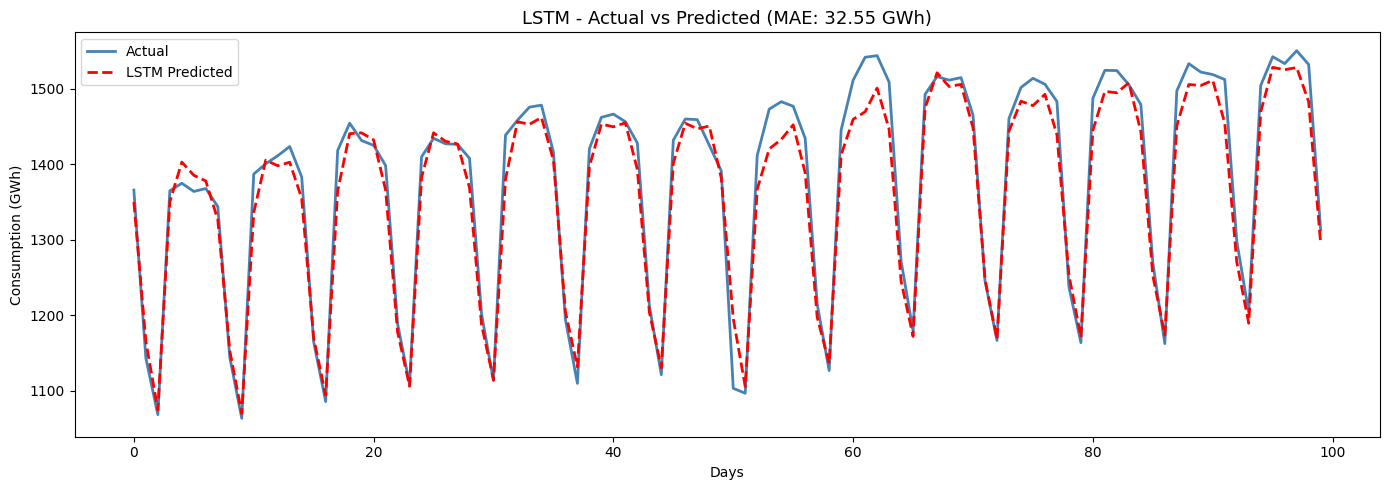

In [20]:
# Predictions karo
y_pred_lstm = model_lstm.predict(X_test_l)

# Wapis original scale par lao (0-1 → GWh)
y_pred_lstm_actual = scaler.inverse_transform(y_pred_lstm)
y_test_lstm_actual = scaler.inverse_transform(y_test_l)

# MAE calculate karo
mae_lstm = mean_absolute_error(y_test_lstm_actual, y_pred_lstm_actual)

print(f"📊 Final Model Comparison:")
print(f"Model 1 - Basic RF   → {mae_old:.2f} GWh")
print(f"Model 2 - Temp RF    → {mae_new:.2f} GWh")
print(f"Model 3 - Lag RF   → {mae_lag:.2f} GWh")
print(f"Model 4 - LSTM     → {mae_lstm:.2f} GWh")

# Graph
plt.figure(figsize=(14, 5))
plt.plot(y_test_lstm_actual[:100], 
         color='steelblue', label='Actual', linewidth=2)
plt.plot(y_pred_lstm_actual[:100], 
         color='red', label='LSTM Predicted', 
         linewidth=2, linestyle='--')
plt.title(f'LSTM - Actual vs Predicted (MAE: {mae_lstm:.2f} GWh)', 
          fontsize=13)
plt.xlabel('Days')
plt.ylabel('Consumption (GWh)')
plt.legend()
plt.tight_layout()
plt.show()